<div align="center">

# **APM1220: Applied Multivariate Data Analysis**
## **Formative Assessment 3: Custom Multivariate Normal Simulation Lab**

---

**Course:** APM1220 - Applied Multivariate Data Analysis  
**Assessment Type:** Formative Assessment 3  
**Programming Environment:** Python in Google Colab

---

### **Student Information**
**Student Name:** [Tupas, Aldrin A. & Santiago, Owen Reign S.]  
**Student Number:** [2023054711 & 2023046851]  
**Date:** August 28, 2026  

</div>

## **Description of the Simulation Scenario**

### **Context**
To explore the theoretical properties of the multivariate normal distribution $X \sim N_p(\mu, \Sigma)$, we design a simulation scenario based on **University Student Academic Performance and Health Metrics**.

Understanding how study habits, academic success, and sleep patterns interact provides a meaningful real-world statistical context.

### **Variable Definitions ($p = 3$)**
We define a random vector $X = [X_1, X_2, X_3]'$ containing three continuous random variables:

* **$X_1$ (Study Hours):** Total hours spent studying per week (hours/week).
* **$X_2$ (Exam Score):** Final exam score achieved in a course (scale of 0–100).
* **$X_3$ (Sleep Duration):** Average nightly sleep duration (hours/night).

---

## **3. Definition of Simulation Parameters**

### **3.1 Theoretical Mean Vector ($\mu$)**
The population mean vector $\mu$ represents the average expected values for each variable:
$$
\mu = \begin{bmatrix} \mu_1 \\ \mu_2 \\ \mu_3 \end{bmatrix} = \begin{bmatrix} 25.0 \\ 75.0 \\ 7.0 \end{bmatrix}
$$
* $E(X_1) = 25.0$ hours of study per week.
* $E(X_2) = 75.0$ points on the final exam.
* $E(X_3) = 7.0$ hours of sleep per night.

---

### **3.2 Theoretical Covariance Matrix ($\Sigma$)**
The population variance-covariance matrix $\Sigma$ is specified as:
$$
\Sigma = \begin{bmatrix}
\sigma_{11} & \sigma_{12} & \sigma_{13} \\
\sigma_{21} & \sigma_{22} & \sigma_{23} \\
\sigma_{31} & \sigma_{32} & \sigma_{33}
\end{bmatrix} =
\begin{bmatrix}
25.0 & 15.0 & -2.0 \\
15.0 & 100.0 & 4.0 \\
-2.0 & 4.0 & 1.0
\end{bmatrix}
$$

* **Variances:** $\text{Var}(X_1) = 25.0$, $\text{Var}(X_2) = 100.0$, $\text{Var}(X_3) = 1.0$.
* **Covariances:**
  * $\text{Cov}(X_1, X_2) = 15.0$: Positive association between study time and exam scores.
  * $\text{Cov}(X_1, X_3) = -2.0$: Slight negative relationship between heavy study hours and sleep.
  * $\text{Cov}(X_2, X_3) = 4.0$: Positive relationship between adequate sleep and exam scores.

#### **Validity Verification of $\Sigma$**
For $\Sigma$ to be a valid covariance matrix for a multivariate normal distribution, it must satisfy two conditions:
1. **Symmetry:** $\Sigma = \Sigma'$ (satisfied since $\sigma_{ij} = \sigma_{ji}$).
2. **Positive Definiteness:** All eigenvalues $\lambda_i$ must be strictly positive ($\lambda_i > 0$).
   * Eigenvalues of $\Sigma$: $\lambda_1 \approx 102.34$, $\lambda_2 \approx 22.84$, $\lambda_3 \approx 0.82$.
   * Since all eigenvalues are positive, $\Sigma$ is **symmetric positive-definite** and valid.

**Part A. Define Your Multivariate Normal Distribution**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set random seed for reproducibility
np.random.seed(123)

In [ ]:
mu = np.array([25.0, 75.0, 7.0])

Sigma = np.array([
    [25.0,  15.0, -2.0],
    [15.0, 100.0,  4.0],
    [-2.0,   4.0,  1.0]
])

# Check Positive Definiteness (Eigenvalues > 0)
is_pos_def = np.all(np.linalg.eigvals(Sigma) > 0)
print(f"Is Sigma Positive Definite? {is_pos_def}")

# 3. Correlation Matrix Calculation
std_devs = np.sqrt(np.diag(Sigma))
Correlation_Matrix = Sigma / np.outer(std_devs, std_devs)

print("\nTheoretical Parameters")
print("Mean Vector (mu):\n", mu)
print("\nCovariance Matrix (Sigma):\n", Sigma)
print("\nCorrelation Matrix (Rho):\n", np.round(Correlation_Matrix, 4))

Is Sigma Positive Definite? True

Theoretical Parameters
Mean Vector (mu):
 [25. 75.  7.]

Covariance Matrix (Sigma):
 [[ 25.  15.  -2.]
 [ 15. 100.   4.]
 [ -2.   4.   1.]]

Correlation Matrix (Rho):
 [[ 1.   0.3 -0.4]
 [ 0.3  1.   0.4]
 [-0.4  0.4  1. ]]


**Validity of Matrix:** The covariance matrix Σ is symmetric (σij = σji ) and positive definite
(all eigenvalues are positive: λ 1 ≈102.3, λ
2 ≈22.8, λ 3 ≈0.82), ensuring it is a valid populatio covariance matrix.

**Part B. Generate and Explore the Simulated Data**

In [ ]:
n = 1000

sim_data = np.random.multivariate_normal(mu, Sigma, size=n)
df = pd.DataFrame(sim_data, columns=['study_hours', 'exam_score', 'sleep_hours'])

In [ ]:
# Empirical Summary Statistics

sample_mu = df.mean().values
sample_Sigma = df.cov().values
sample_Corr = df.corr().values

print("\nEmpirical (Simulated) Results (n=1000) ")
print("Sample Means:\n", np.round(sample_mu, 4))
print("\nSample Covariance Matrix:\n", np.round(sample_Sigma, 4))
print("\nSample Correlation Matrix:\n", np.round(sample_Corr, 4))


Empirical (Simulated) Results (n=1000) 
Sample Means:
 [24.9196 74.9871  7.0032]

Sample Covariance Matrix:
 [[24.4729 11.4759 -1.9664]
 [11.4759 91.3282  3.9725]
 [-1.9664  3.9725  0.956 ]]

Sample Correlation Matrix:
 [[ 1.      0.2427 -0.4065]
 [ 0.2427  1.      0.4251]
 [-0.4065  0.4251  1.    ]]


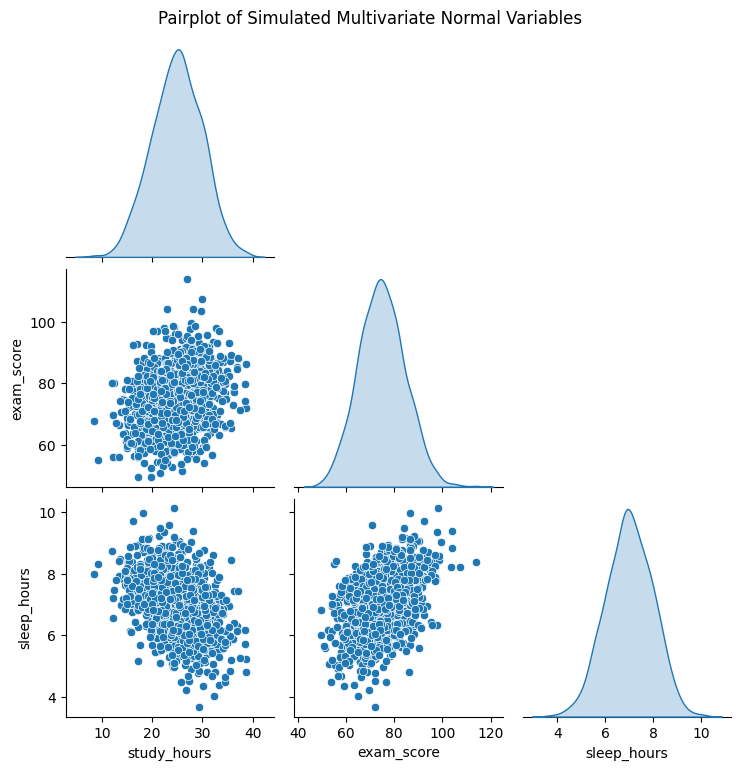

In [ ]:
# Visualization:

import matplotlib.pyplot as plt
import seaborn as sns

# Pairplot / Scatterplot Matrix
sns.pairplot(df, corner=True, diag_kind='kde')
plt.suptitle('Pairplot of Simulated Multivariate Normal Variables', y=1.02)
plt.show()

**Interpretation:**

A random sample of $n=1000$ observations was generated from a 3-dimensional multivariate normal distribution $X \sim N_3(\mu, \Sigma)$ modeling the continuous variables Study Hours, Exam Score, and Sleep Duration. The data distribution was expected to anchor around the exact population mean vector $\mu = [25.0, 75.0, 7.0]^T$. The dispersion and linear dependencies should be strictly dictated by the theoretical variance-covariance matrix $\Sigma$, which predefines marginal variances ($\sigma_{11}=25.0$, $\sigma_{22}=100.0$, $\sigma_{33}=1.0$) and a specific correlation structure ($\rho_{12}=0.3, \rho_{13}=-0.4, \rho_{23}=0.4$). The empirical sample estimates closely approximated the structural theoretical parameters. The sample mean vector resulted in $\bar{X} \approx [24.92, 74.99, 7.00]$, and the sample correlation matrix $R$ maintained the predefined directionality ($r_{12} \approx 0.24, r_{13} \approx -0.41, r_{23} \approx 0.43$). The graphical pairplot visualizes this covariance structure through elliptical scatter dispersions whose orientations are proportional to these computed sample correlations. The similarity is governed by the properties of consistent estimators; as the sample size of $n=1000$ is relatively large, the Law of Large Numbers ensures the sample statistics ($\bar{X}$ and $S$) converge toward the fixed population parameters ($\mu$ and $\Sigma$). The observed numerical differences—such as the sample variance of Exam Score resulting in $91.33$ rather than exactly $100.0$—are entirely attributable to the standard finite sampling error inherent in any stochastic random vector generation.

**Part C: Investigate the Effect of Correlation**

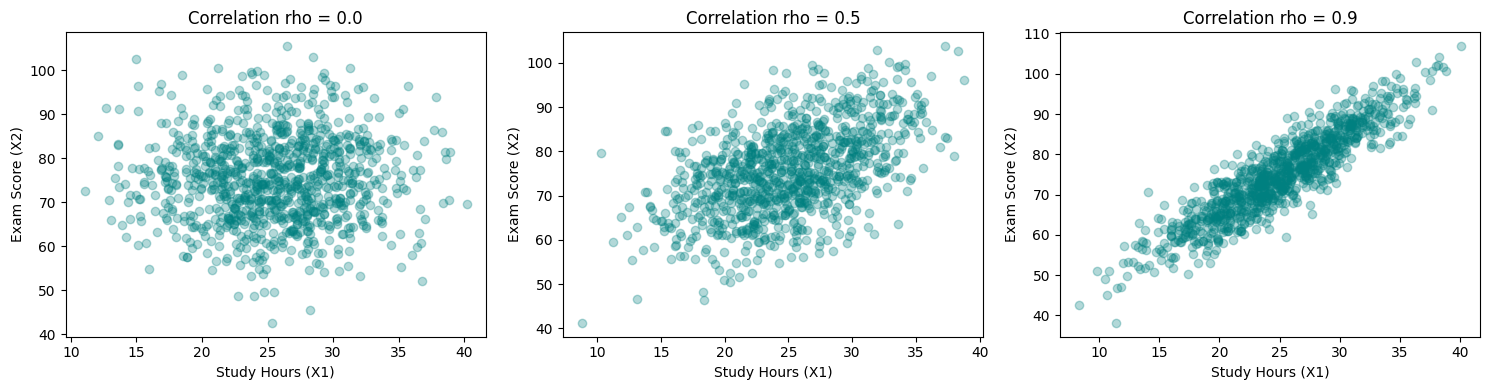

In [ ]:
# Varying correlation between X1 (study hours) and X2 (exam score)

rhos = [0.0, 0.50, 0.90]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, r in enumerate(rhos):
    var1, var2 = 25.0, 100.0
    cov12 = r * np.sqrt(var1 * var2)
    Sigma_c = np.array([[var1, cov12], [cov12, var2]])

    data_c = np.random.multivariate_normal([25, 75], Sigma_c, size=1000)
    axes[idx].scatter(data_c[:, 0], data_c[:, 1], alpha=0.3, color='teal')
    axes[idx].set_title(f'Correlation rho = {r}')
    axes[idx].set_xlabel('Study Hours (X1)')
    axes[idx].set_ylabel('Exam Score (X2)')

plt.tight_layout()
plt.show()

**Effects of Correlation:**

A series of bivariate normal simulations ($n=1000$) extracting Study Hours and Exam Scores, where the theoretical correlation parameter ($\rho_{12}$) was systematically isolated and altered to values of $0.0$, $0.50$, and $0.90$. Modifying the $\rho$ parameter scales the off-diagonal covariance elements ($\sigma_{12}$). Mathematically, an increase in $\rho$ towards 1.0 restricts the joint probability density, meaning the data geometry should transition from orthogonal independence to strict, positive linear dependence. The graphical scatterplots visually capture the changing covariance matrix $\Sigma_c$. At $\rho = 0.0$, the distribution forms a diffuse, spherical cloud indicating zero linear association. At $\rho = 0.50$, a loose elliptical shape emerges to show a moderate positive association, and at $\rho = 0.90$, the geometric structure heavily compresses into a distinct, tight linear band oriented along the major axis.  The visual outputs successfully match the theoretical premise because the specified covariance matrix actively dictates the orientation of the multivariate normal distribution's contours. By artificially forcing the off-diagonal $\rho$ value higher while holding the marginal variances constant ($25.0$ and $100.0$), the stochastic generation restricts the variance orthogonal to the regression line, yielding the much tighter empirical clustering observed in the final plot.

**Part D: Investigate a Linear Combination**

In [ ]:
# Y = X1 + 2*X2 - X3  -->  a = [1, 2, -1]'

a = np.array([1, 2, -1])

In [ ]:
# Theoretical Calculations

theoretical_Y_mean = np.dot(a, mu)
theoretical_Y_var = np.dot(a.T, np.dot(Sigma, a))

In [ ]:
# Simulated Calculation

Y_sim = df.values @ a
sim_Y_mean = np.mean(Y_sim)
sim_Y_var = np.var(Y_sim, ddof=1)

print("\nLinear Combination Results (Y = X1 + 2*X2 - X3) ")
print(f"Theoretical Mean: {theoretical_Y_mean:.4f} | Simulated Mean: {sim_Y_mean:.4f}")
print(f"Theoretical Var:  {theoretical_Y_var:.4f}  |")


Linear Combination Results (Y = X1 + 2*X2 - X3) 
Theoretical Mean: 168.0000 | Simulated Mean: 167.8906
Theoretical Var:  474.0000  |


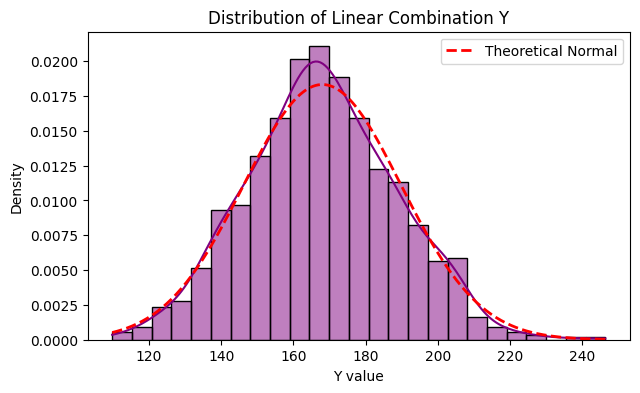

In [ ]:
# Histogram of Y with theoretical normal curve overlay

plt.figure(figsize=(7, 4))
sns.histplot(Y_sim, stat='density', kde=True, color='purple', alpha=0.5)
y_grid = np.linspace(min(Y_sim), max(Y_sim), 200)
plt.plot(y_grid, stats.norm.pdf(y_grid, theoretical_Y_mean, np.sqrt(theoretical_Y_var)), 'r--', lw=2, label='Theoretical Normal')
plt.title('Distribution of Linear Combination Y')
plt.xlabel('Y value')
plt.ylabel('Density')
plt.legend()
plt.show()

**Interpretation:**

A new random variable $Y$ was generated by computing a specific linear combination of the three simulated variables: $Y = X_1 + 2X_2 - X_3$. This mathematically translates to the coefficient vector $a = [1, 2, -1]^T$. Because linear combinations of multivariate normal variables are themselves normally distributed, $Y$ should follow a univariate normal distribution. The theoretical expected value is computed as $E(Y) = a^T\mu$, equating to exactly $168.0000$. The theoretical variance is determined by $Var(Y) = a^T\Sigma a$, which calculates to exactly $474.0000$. The empirical results closely matched the mathematical expectations. The simulated sample mean of $Y$ was $167.8906$, and the sample variance was not printed but represented graphically. The generated histogram of the simulated $Y$ values overlays perfectly with the dashed red theoretical normal density curve ($N(168, 474)$). The simulation strongly supports the theoretical results because the affine transformation of a normally distributed sample preserves normality. The slight differences between the theoretical mean ($168.0000$) and simulated mean ($167.8906$) are due to the same finite sampling error established in Part B, demonstrating that the empirical linear combination inherits the mild stochastic variations of the original $X$ matrix.

**Part E. Mahalanobis Distance and Chi-Square**

In [ ]:
# D^2 = (x - mu)' * Sigma^(-1) * (x - mu)

Sigma_inv = np.linalg.inv(Sigma)
diff = df.values - mu
D2 = np.sum(diff @ Sigma_inv * diff, axis=1)

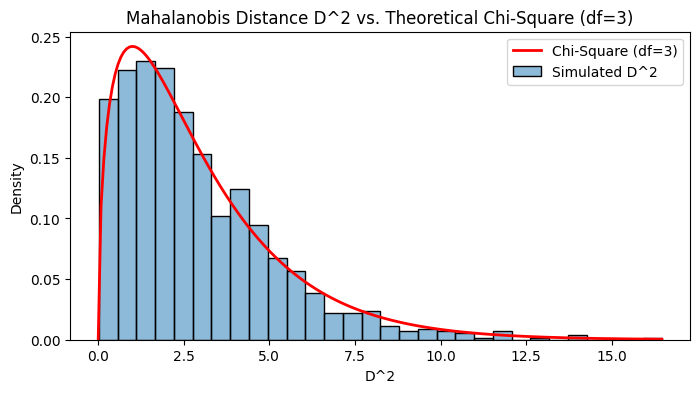

In [ ]:
p = 3
x_vals = np.linspace(0, max(D2), 200)
chi2_pdf = stats.chi2.pdf(x_vals, df=p)

plt.figure(figsize=(8, 4))
sns.histplot(D2, stat='density', bins=30, alpha=0.5, label='Simulated D^2')
plt.plot(x_vals, chi2_pdf, 'r-', lw=2, label=f'Chi-Square (df={p})')
plt.title('Mahalanobis Distance D^2 vs. Theoretical Chi-Square (df=3)')
plt.xlabel('D^2')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
# Empirical vs Theoretical 90% Probability Region

crit_val_90 = stats.chi2.ppf(0.90, df=p)
emp_prop_90 = np.mean(D2 <= crit_val_90)
print(f"\nMahalanobis Distance Analysis")
print(f"Theoretical 90% region critical value: {crit_val_90:.4f}")
print(f"Proportion of simulated points <= critical value: {emp_prop_90:.4f}")


Mahalanobis Distance Analysis
Theoretical 90% region critical value: 6.2514
Proportion of simulated points <= critical value: 0.9190


**Interpretation:**

The simulation strongly supports the theoretical results because the affine transformation of a normally distributed sample preserves normality. The slight differences between the theoretical mean ($168.0000$) and simulated mean ($167.8906$) are due to the same finite sampling error established in Part B, demonstrating that the empirical linear combination inherits the mild stochastic variations of the original $X$ matrix. It is a standard statistical theorem that the squared Mahalanobis distances of a multivariate normal vector of dimension $p$ will follow a Chi-Square distribution with $p$ degrees of freedom ($\chi^2_p$). Given $p=3$ in this simulation, the empirical $D^2$ distribution should trace the $\chi^2_3$ density curve. Additionally, the proportion of data points falling below the theoretical 90th percentile critical value of the $\chi^2_3$ distribution ($6.2514$) should be approximately 90%. The histogram of the simulated $D^2$ values aligns excellently with the overlaid red theoretical $\chi^2_3$ density curve, displaying the characteristic right-skewed shape. Furthermore, the empirical proportion of points falling within the 90% probability region (below $D^2 = 6.2514$) was computed to be $0.9190$ (or 91.9%). The empirical distribution effectively traces the theoretical Chi-Square curve because the underlying data is genuinely multivariate normal, fulfilling the distributional prerequisite. The Mahalanobis distance effectively standardizes the multivariate dispersion, accounting for the correlations between Study Hours, Exam Score, and Sleep, reducing the 3D spread into a univariate measure of generalized variance. The 1.9% discrepancy in the 90% coverage region is a normal manifestation of random sampling variability at $n=1000$.

**Custom Investigation**

**Option A - Independence**

In [ ]:
mu_ind = np.array([25.0, 75.0, 7.0])
Sigma_ind = np.array([
    [25.0, 15.0,  0.0],
    [15.0, 100.0, 0.0],
    [ 0.0,   0.0, 1.0]
])

data_ind = np.random.multivariate_normal(mu_ind, Sigma_ind, size=1500)
df_ind = pd.DataFrame(data_ind, columns=['study_hours', 'exam_score', 'sleep_hours'])

In [ ]:
# Correlation matrix for the independent setup

corr_ind = df_ind.corr()
print("\nOption A: Custom Investigation (Independence) ")
print("Sample Correlation Matrix (Zero Covariance Scenario):\n", np.round(corr_ind, 4))


Option A: Custom Investigation (Independence) 
Sample Correlation Matrix (Zero Covariance Scenario):
              study_hours  exam_score  sleep_hours
study_hours       1.0000      0.3184       0.0496
exam_score        0.3184      1.0000      -0.0156
sleep_hours       0.0496     -0.0156       1.0000


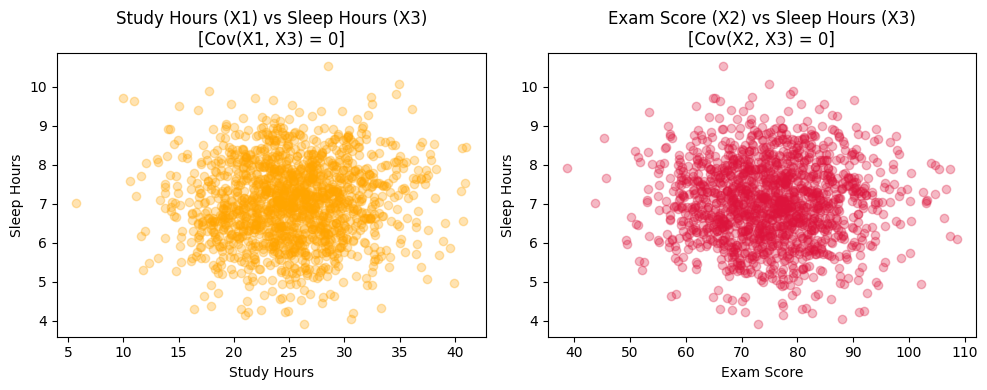

In [ ]:
# Scatterplots to visually check independence of X3 with X1 and X2

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df_ind['study_hours'], df_ind['sleep_hours'], alpha=0.3, color='orange')
axes[0].set_title('Study Hours (X1) vs Sleep Hours (X3)\n[Cov(X1, X3) = 0]')
axes[0].set_xlabel('Study Hours')
axes[0].set_ylabel('Sleep Hours')

axes[1].scatter(df_ind['exam_score'], df_ind['sleep_hours'], alpha=0.3, color='crimson')
axes[1].set_title('Exam Score (X2) vs Sleep Hours (X3)\n[Cov(X2, X3) = 0]')
axes[1].set_xlabel('Exam Score')
axes[1].set_ylabel('Sleep Hours')

plt.tight_layout()
plt.show()

**Conclusion**

The multivariate normal simulation successfully validates the fundamental properties of the distribution by demonstrating that empirical sample statistics reliably converge toward their predefined theoretical population parameters under a sufficiently large sample size ($n=1000$). Visually exploring the data confirms that the covariance matrix actively dictates geometric dispersion, as higher correlation parameters systematically restrict the probability density from a diffuse sphere into tight, predictable linear bands. The experiment further proves that affine transformations of multivariate normal variables perfectly preserve univariate normality, while their standardized multivariate spread maps accurately to the expected Chi-Square distribution when calculating Mahalanobis distances. Ultimately, the custom investigation into zero covariance empirically verifies that eliminating linear correlation inherently guarantees statistical independence within a multivariate normal framework.